## Environment setup

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import scipy
import importlib
import uproot
import awkward as ak
import matplotlib.pyplot as plt
from matplotlib import colors
from termcolor import colored


import uproot

params = {'legend.fontsize': 'xx-large',
          'figure.figsize': (10, 7),
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

##constants. Energy units is MeV
amu = 931.49410242
mO16 = 16*amu + -4.7370022 
mHe4 = 4*amu + 2.42491587

### Relation between $cos(\theta)$ in LAB and CM systems

In [45]:
def thetaLAB(thetaCM, betaCM, betaPartCM):
    gamma = 1.0/np.sqrt(1 - betaCM**2)
    theta = np.arctan2(np.sin(thetaCM), gamma*(np.cos(thetaCM) + betaCM/betaPartCM) )
    return theta
##########################################
def eGammaFromFitParams(p):
    beta = 1.0/np.sqrt(2*mHe4)*p[:,1]/np.sqrt(p[:,0])
    result = beta*mO16/(1-beta)
    return result
##########################################  
def func_Gauss(x, a0, b0, c0):
    return a0*scipy.stats.norm.pdf(x, b0, c0)# + a1*scipy.stats.norm.pdf(x, b1, c1)
########################################## 
def func_Linear(x,p0,p1):
    return p0 + p1*x
########################################## 
def fitThetaSlices(df, thetaBins, massBins, doPlot=True):

    nPads = int(np.ceil(np.sqrt(len(thetaBins))))
    fig, axes = plt.subplots(nPads, nPads, figsize=(17,15))
    
    muValues = []

    for iBin in range(len(thetaBins)-1):
        
        iRow = int(iBin/nPads) 
        iColumn = iBin%nPads
        mask  = (df["alpha_cosThetaBEAM"]>thetaBins[iBin])&(df["alpha_cosThetaBEAM"]<thetaBins[iBin+1])
        
        counts, bins, _ = axes[iRow, iColumn].hist(x=df["alpha_energy"][mask], bins=massBins, label="data");
        binCenters = (bins+np.roll(bins, -1))/2.0
        binCenters = binCenters[:-1]

        try:
            sigma = np.where(counts>0, np.sqrt(counts), 1)
            #sigma = np.ones_like(counts)
            paramsFit, covarianceFit = scipy.optimize.curve_fit(f=func_Gauss, 
                                                                xdata=binCenters, ydata=counts, sigma=sigma, 
                                                                absolute_sigma=True)
        except RuntimeError:
            muValues.append(-1)
            continue

        y_fit = func_Gauss(binCenters, *paramsFit)
        axes[iRow, iColumn].plot(binCenters, y_fit, lw=3, color='red', alpha=0.6, label="fit")
        
        rangeLabel = (r"${:2.1}<\cos(\theta)<{:2.1f}$".format(thetaBins[iBin], thetaBins[iBin+1]))
        axes[iRow, iColumn].legend(loc="upper right", title=rangeLabel)
        muValue = paramsFit[1]
        if np.max(counts)<10:
            muValue *= -1
        muValues.append(muValue)

    binCenters = (thetaBins+np.roll(thetaBins, shift=-1))/2.0   
    binCenters = binCenters[:-1]
    axes[-1][-1].plot(binCenters, muValues, "ro")
    axes[-1][-1].set_xlim([-1.1,1.1])
    plt.subplots_adjust(bottom=0.15, left=0.05, right=0.95, wspace=0.4)
    if not doPlot:
        plt.close(fig)
    return np.array(muValues)
########################################## 
########################################## 
def fitEgamma(thetaBins, muValues, doPlot=True):

    binCenters = (thetaBins+np.roll(thetaBins, shift=-1))/2.0   
    binCenters = binCenters[:-1]

    mask = muValues>0
    print(muValues)

    paramsFit, covarianceFit = scipy.optimize.curve_fit(f=func_Linear, xdata=binCenters[mask], 
                                                        ydata=muValues[mask])
    
    x = np.linspace(-1,1,100)
    y = func_Linear(x, *paramsFit)
    
    fig, axes = plt.subplots(1, figsize=(5,5))    
    axes.plot(binCenters, np.abs(muValues), "ro")
    axes.plot(binCenters[np.logical_not(mask)], np.abs(muValues[np.logical_not(mask)]), "bo", label="excluded\nfrom fit")
    axes.plot(x, y);
    axes.set_xlabel(r"$\cos(\theta)$")
    axes.set_ylabel("E [MeV]")
    axes.legend(); 
    if not doPlot:
        plt.close(fig)

    paramsFit = np.array([paramsFit])
    print(colored("Fitted T*:","blue"), paramsFit)
    return eGammaFromFitParams(paramsFit)
########################################## 
########################################## 
def getMCData(Egamma, THe4Star, nEvents = 10000):
     cosThetaStar = np.random.default_rng().uniform(low=-1, high=1, size=nEvents)
     EStar = THe4Star + mHe4   
     pStar = np.sqrt(EStar**2 - mHe4**2)   
     pLStar = pStar*cosThetaStar
     pTStar = pStar*np.sqrt(1-cosThetaStar*cosThetaStar)
                 
     beta = Egamma/(Egamma+mO16)
     gamma = 1/np.sqrt(1-beta**2)   
                        
     ELab = gamma*(EStar + beta*pLStar)
     pLLab = gamma*(pLStar + beta*EStar) 
     pTLab = pTStar   
    
     cosThetaLab = pLLab/np.sqrt(pLLab**2 + pTLab**2)  
    
     df = pd.DataFrame()
     df["alphaEnergy"] = (ELab - mHe4)*np.random.default_rng().normal(loc=0.8, scale=0.05, size=nEvents)
     df["cosTheta"] = cosThetaLab
     df["cosThetaStar"] = cosThetaStar
     return df 
########################################## 
def getData(fileName):
   
    fileROOT = uproot.open(fileName)
    tree = fileROOT['Tree_2prong_events']
    data = tree['data'].array(library='np')
    df = pd.DataFrame(data)
    df.describe()
    df.dropna(inplace=True)
    return df
########################################## 

E gamma: 13.1
E alpha: 0.1


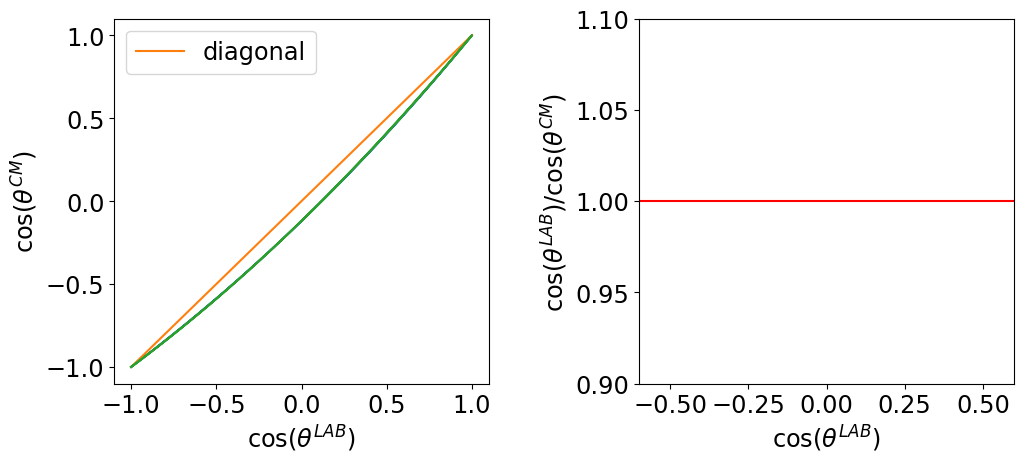

In [41]:
fig, axes = plt.subplots(1,2, figsize=(10,5))

Egamma = 13.1
THe4 = 0.1

thetaCM = np.linspace(-np.pi, np.pi, 100)

betaCM = Egamma/(Egamma+mO16)
gammaHe4 = (THe4 + mHe4)/mHe4
betaHe4 = np.sqrt(1 - 1/gammaHe4**2)

x = np.cos(thetaLAB(thetaCM, betaCM, betaHe4))
y = np.cos(thetaCM)
axes[0].plot(x,y);
axes[0].plot((-1,1), (-1,1), label="diagonal")
axes[0].legend()

c = np.cos(thetaLAB(np.pi/2, -betaCM, betaHe4));
a = -c
b = 1
axes[0].plot(x, a*x**2+b*x+c)
axes[0].set_xlabel(r"$\cos(\theta^{LAB})$")
axes[0].set_ylabel(r"$\cos(\theta^{CM})$")

df = getMCData(Egamma, THe4)
#x = df["cosTheta"]
#y = df["cosThetaStar"]       
axes[1].plot(x,x/y, "bo")
axes[1].plot([-1,1], [1,1], "r")
axes[1].set_xlabel(r"$\cos(\theta^{LAB})$")
axes[1].set_ylabel(r"$\cos(\theta^{LAB})/\cos(\theta^{CM})$");
axes[1].set_xlim([-0.6,0.6])
axes[1].set_ylim([0.9,1.1])
plt.subplots_adjust(bottom=0.15, left=0.05, right=0.95, wspace=0.4)

print(colored("E gamma:","blue"),Egamma)
print(colored("E alpha:","blue"),THe4)

In [47]:
datasets = [
["2022-04-12T00-20-27", 11.10, np.linspace(2.3,3.8,40)],
["2022-04-12T01-36-08", 11.10, np.linspace(2.3,3.8,40)],
["2022-04-12T03-46-08", 11.10, np.linspace(2.3,3.8,40)], 
["2022-04-12T04-59-35", 11.10, np.linspace(2.3,3.8,40)],    
["2022-04-12T08-03-44", 11.50, np.linspace(2.6,3.5,40)],
["2022-04-12T10-35-16", 11.90, np.linspace(2.6,3.5,40)],
["2022-04-12T11-59-23", 11.90, np.linspace(2.6,3.5,40)],
["2022-04-12T13-19-04" , 11.90, np.linspace(2.6,3.5,40)],  
["2022-04-12T15-28-17", 12.30, np.linspace(3.2,4.6,40)],
#["2022-04-12T17-39-06", 12.70, np.linspace(1.2,5,40)],
#["2022-04-13T09-50-40", 13.10, np.linspace(2.5,4.5,20)],
#["2022-04-14T18-33-08", 9.85,  np.linspace(1.9,2.2,20)]
#["2022-04-15T11-12-52", 8.86,  np.linspace(1,2.5,40)],
#["2022-04-15T18-40-41", 8.86,  np.linspace(1,2.5,40)]
]

datasets = [
["2022-04-12T20-05-29", 13.10, np.linspace(2.5,4.5,20)],
]

[-1.          4.26330894  4.24475416  4.20248121  4.16836628  4.14972288
  4.13349505  4.11470742  4.03184859  4.08442023  4.12435567  4.13238628
  4.16403095  4.22191493  4.27065376  4.30868251  4.3483668   2.6398709
  2.84112109  2.9502693 ]
Fitted T*: [[ 3.99527432 -0.54258429]]
[-46.68921249]


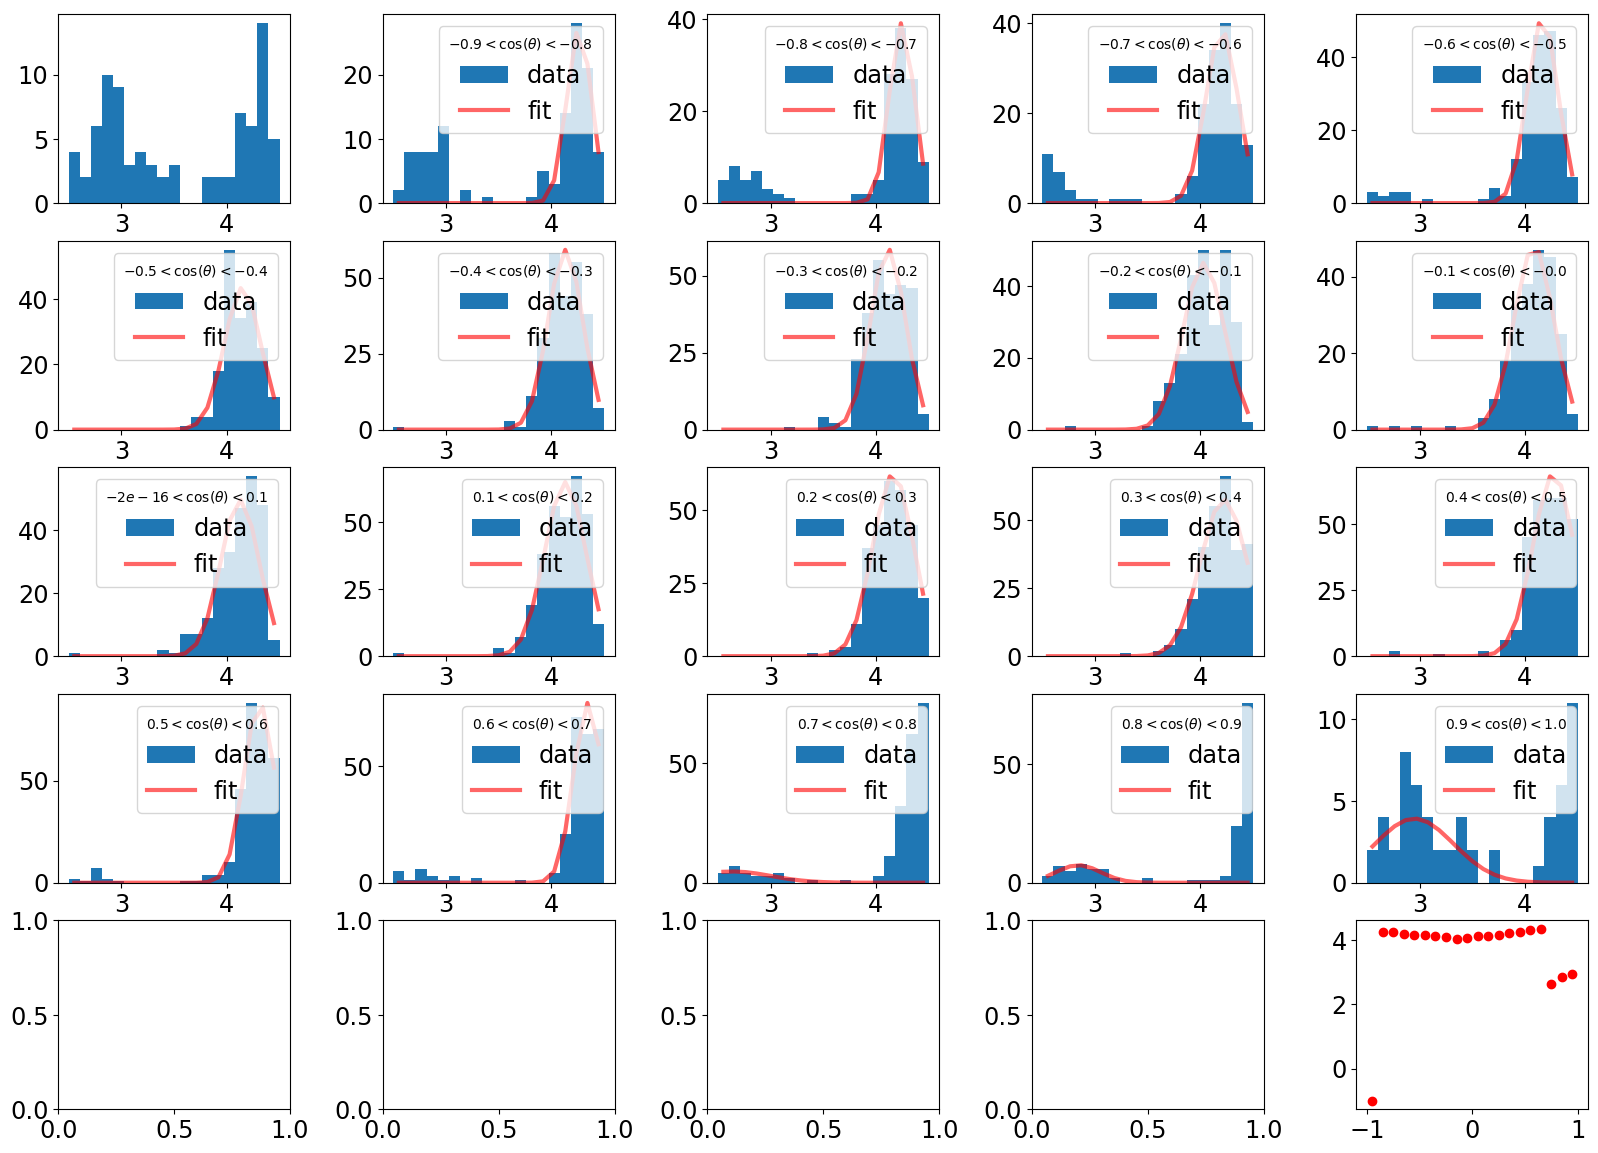

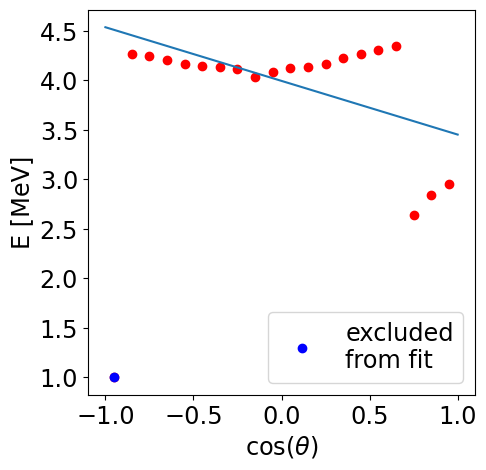

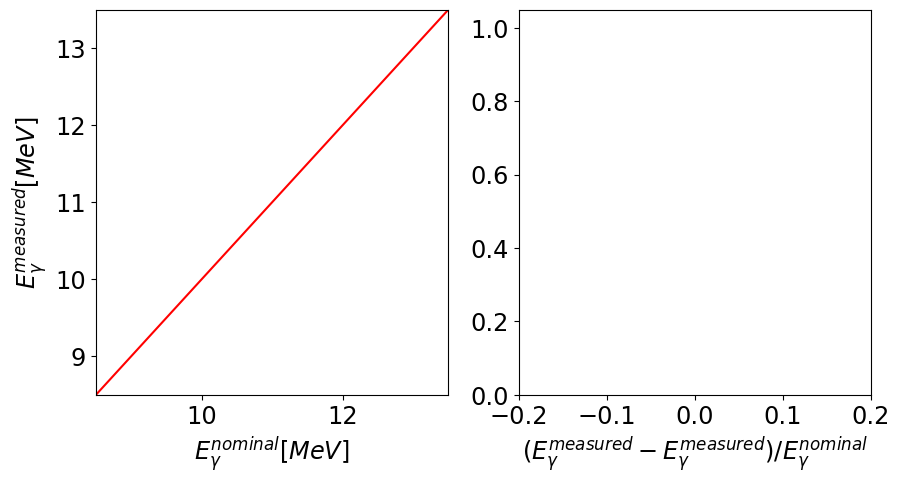

In [48]:
prefixPath = "/scratch_hdd/akalinow/ELITPC/TPCReco/build_ZPS_2024/resources/HIgS_2022/"
thetaBins = np.arange(-1.0,1.1,0.1)

eGamma = []
eGammaNominal = []
'''
########################################## 
def func_Gauss(x, a0, b0, c0, a1, b1, c1):
    term1= a0/np.sqrt(2*np.pi*c0)*scipy.stats.norm.pdf(x, b0, c0)
    term2 =a1/np.sqrt(2*np.pi*c1)*scipy.stats.norm.pdf(x, b1, c1)
    return term1 + term2
########################################## 
'''
for item in datasets:
    fileName = prefixPath+"/plots/"+item[0]+"/Trees.root"
    df = getData(fileName)
    #df = getMCData(Egamma=item[1], THe4Star=item[2].mean(), nEvents = 10000)
    eGammaNominal.append(item[1])
    massBins = item[2]
    muValues = fitThetaSlices(df, thetaBins, massBins, doPlot=True)
    eGamma.append(fitEgamma(thetaBins, muValues, doPlot=True)[0])
      
eGamma = np.array(eGamma)
eGammaNominal = np.array(eGammaNominal)

print(eGamma)

fig, axes = plt.subplots(1,2, figsize=(10,5))
axes[0].plot(eGammaNominal,eGamma, "bo")  
axes[0].plot([8.5,13.5], [8.5,13.5], "r")
axes[0].set_xlim([8.5,13.5])
axes[0].set_ylim([8.5,13.5])
axes[0].set_xlabel(r"$E_{\gamma}^{nominal} [MeV]$")
axes[0].set_ylabel(r"$E_{\gamma}^{measured} [MeV]$")

axes[1].hist((eGamma-eGammaNominal)/eGammaNominal)
axes[1].set_xlabel(r"$(E_{\gamma}^{measured} - E_{\gamma}^{measured})/E_{\gamma}^{nominal}$")
axes[1].set_xlim([-0.2,0.2]);

In [ ]:
%%time 

minEgamma = 8
maxEgamma = 13
THe4Star = 3.0
massBins = np.linspace(1.5,5.0,20)
thetaBins = np.linspace(-1.05,1.05,24)

eGamma = []
eGammaNominal = []

for iTry in range(0,100):
    Egamma = np.random.default_rng().uniform(low=minEgamma, high=maxEgamma)
    df = getMCData(Egamma, THe4Star=THe4Star, nEvents = 10000) 
    muValues = fitThetaSlices(df, thetaBins, massBins, doPlot=False)
    eGamma.append(fitEgamma(thetaBins, muValues, doPlot=False)[0])
    eGammaNominal.append(Egamma)

eGamma = np.array(eGamma)
eGammaNominal = np.array(eGammaNominal)

fig, axes = plt.subplots(1,2, figsize=(10,5))
axes[0].plot(eGammaNominal,eGamma, "bo")  
#axes[0].plot(eGammaNominal,eGamma/np.sqrt(0.9), "go") 
axes[0].plot([8,14], [8,14], "r")
axes[0].set_xlim([8,14])
axes[0].set_ylim([8,14])
axes[0].set_xlabel(r"$E_{\gamma}^{nominal} [MeV]$")
axes[0].set_ylabel(r"$E_{\gamma}^{measured} [MeV]$")

weights = np.full_like(eGamma, 1.0/len(eGamma))
axes[1].hist((eGamma-eGammaNominal)/eGammaNominal, weights = weights)
axes[1].set_xlabel(r"$(E_{\gamma}^{measured} - E_{\gamma}^{measured})/E_{\gamma}^{nominal}$")
axes[1].set_xlim([-0.5,0.5]); 

yText = axes[1].get_ylim()[1]
muLabel = (r"$\mu = {:3.2f}$".format(((eGamma-eGammaNominal)/eGammaNominal).mean()))
axes[1].text(0.15, 0.9*yText, muLabel, size=20)
resolutionLabel = (r"$\sigma = {:3.2f}$".format(((eGamma-eGammaNominal)/eGammaNominal).std()))
axes[1].text(0.15, 0.8*yText, resolutionLabel, size=20)
print("Relative resolution standard devtion: {:3.2f}".format(((eGamma-eGammaNominal)/eGammaNominal).std()))
plt.subplots_adjust(bottom=0.15, left=0.05, right=0.95, wspace=0.4)